<a href="https://colab.research.google.com/github/smithakattuboina/smithakattuboina./blob/main/phase_!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# STEP 1: Loading the Dataset


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/KosteckiDillon.csv"
df = pd.read_csv(url)


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (4152, 10)

First 5 rows:


,rownames,id,time,dos,hatype,age,airq,medication,headache,sex
0,1,1,-11,753,Aura,30,9.0,continuing,yes,female
1,2,1,-10,754,Aura,30,7.0,continuing,yes,female
2,3,1,-9,755,Aura,30,10.0,continuing,yes,female
3,4,1,-8,756,Aura,30,13.0,continuing,yes,female
4,5,1,-7,757,Aura,30,18.0,continuing,yes,female


In [ ]:

# STEP 2: Basic Statistical Analysis

print("Dataset Info:")
df.info()

print("\nSummary Statistics (Numerical Columns):")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    4152 non-null   int64  
 1   id          4152 non-null   int64  
 2   time        4152 non-null   int64  
 3   dos         4152 non-null   int64  
 4   hatype      4152 non-null   object 
 5   age         4152 non-null   int64  
 6   airq        4152 non-null   float64
 7   medication  4152 non-null   object 
 8   headache    4152 non-null   object 
 9   sex         4152 non-null   object 
dtypes: float64(1), int64(5), object(4)
memory usage: 324.5+ KB

Summary Statistics (Numerical Columns):


,rownames,id,time,dos,age,airq
count,4152.000000,4152.000000,4152.000000,4152.000000,4152.000000,4152.000000
mean,2076.500000,66.386802,15.455684,646.705925,42.363921,24.826012
std,1198.723488,39.121812,21.737211,335.770123,11.201244,9.514274
min,1.000000,1.000000,-29.000000,98.000000,18.000000,3.000000
25%,1038.750000,33.000000,3.000000,384.000000,33.000000,18.000000
50%,2076.500000,67.000000,12.000000,623.000000,44.000000,24.000000
75%,3114.250000,100.000000,24.000000,950.000000,50.000000,29.000000
max,4152.000000,133.000000,99.000000,1239.000000,66.000000,73.000000


In [ ]:

print("Summary Statistics (Categorical Columns):")
df.describe(include='object')

Summary Statistics (Categorical Columns):


,hatype,medication,headache,sex
count,4152,4152,4152,4152
unique,3,3,2,2
top,No Aura,continuing,yes,female
freq,1985,2386,2666,3545


In [ ]:

print("Column Names:", list(df.columns))
print("\nData Types:\n", df.dtypes)

Column Names: ['rownames', 'id', 'time', 'dos', 'hatype', 'age', 'airq', 'medication', 'headache', 'sex']

Data Types:
 rownames        int64
id              int64
time            int64
dos             int64
hatype         object
age             int64
airq          float64
medication     object
headache       object
sex            object
dtype: object


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric Columns:", numeric_cols)

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"Mean   : {df[col].mean():.2f}")
    print(f"Median : {df[col].median():.2f}")
    print(f"Mode   : {df[col].mode()[0]}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"Min    : {df[col].min()}")
    print(f"Max    : {df[col].max()}")

Numeric Columns: ['rownames', 'id', 'time', 'dos', 'age', 'airq']

--- rownames ---
Mean   : 2076.50
Median : 2076.50
Mode   : 1
Std Dev: 1198.72
Variance: 1436938.00
Min    : 1
Max    : 4152

--- id ---
Mean   : 66.39
Median : 67.00
Mode   : 55
Std Dev: 39.12
Variance: 1530.52
Min    : 1
Max    : 133

--- time ---
Mean   : 15.46
Median : 12.00
Mode   : 5
Std Dev: 21.74
Variance: 472.51
Min    : -29
Max    : 99

--- dos ---
Mean   : 646.71
Median : 623.00
Mode   : 213
Std Dev: 335.77
Variance: 112741.58
Min    : 98
Max    : 1239

--- age ---
Mean   : 42.36
Median : 44.00
Mode   : 46
Std Dev: 11.20
Variance: 125.47
Min    : 18
Max    : 66

--- airq ---
Mean   : 24.83
Median : 24.00
Mode   : 24.8
Std Dev: 9.51
Variance: 90.52
Min    : 3.0
Max    : 73.0


In [ ]:

# STEP 3: Handling Missing Data
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nPercentage of Missing Values per Column:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values per Column:
rownames      0
id            0
time          0
dos           0
hatype        0
age           0
airq          0
medication    0
headache      0
sex           0
dtype: int64

Percentage of Missing Values per Column:
rownames      0.0
id            0.0
time          0.0
dos           0.0
hatype        0.0
age           0.0
airq          0.0
medication    0.0
headache      0.0
sex           0.0
dtype: float64


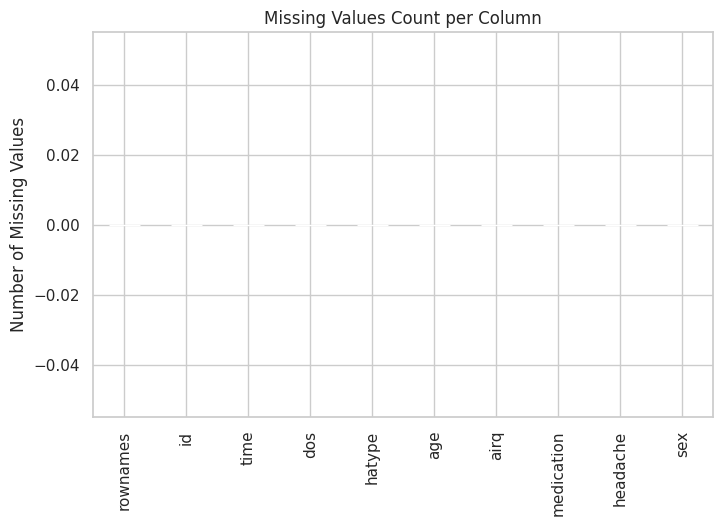

In [ ]:

plt.figure(figsize=(8,5))
df.isnull().sum().plot(kind='bar', color='salmon')
plt.title("Missing Values Count per Column")
plt.ylabel("Number of Missing Values")
plt.show()

In [ ]:

print("Rows before handling missing data:", df.shape[0])


numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after handling:")
print(df.isnull().sum())

Rows before handling missing data: 4152

Missing values after handling:
rownames      0
id            0
time          0
dos           0
hatype        0
age           0
airq          0
medication    0
headache      0
sex           0
dtype: int64


In [ ]:

# STEP 4: Data Cleaning

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0' column.")
elif 'rownames' in df.columns:
    df.drop(columns=['rownames'], inplace=True)
    print("Dropped 'rownames' column.")

print("Columns after dropping index column:", list(df.columns))

Dropped 'rownames' column.
Columns after dropping index column: ['id', 'time', 'dos', 'hatype', 'age', 'airq', 'medication', 'headache', 'sex']


In [ ]:

print("Number of duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 1
Shape after removing duplicates: (4151, 9)


In [ ]:

categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values in each categorical column after cleaning:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Categorical columns: ['hatype', 'medication', 'headache', 'sex']

Unique values in each categorical column after cleaning:
hatype: ['aura' 'no aura' 'mixed']
medication: ['continuing' 'reduced' 'none']
headache: ['yes' 'no']
sex: ['female' 'male']


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected (range: {lower_bound:.2f} to {upper_bound:.2f})")

id: 0 outliers detected (range: -67.50 to 200.50)
time: 210 outliers detected (range: -28.50 to 55.50)
dos: 0 outliers detected (range: -465.00 to 1799.00)
age: 0 outliers detected (range: 7.50 to 75.50)
airq: 157 outliers detected (range: 1.50 to 45.50)


In [ ]:

print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (4151, 9)


,id,time,dos,hatype,age,airq,medication,headache,sex
0,1,-11,753,aura,30,9.0,continuing,yes,female
1,1,-10,754,aura,30,7.0,continuing,yes,female
2,1,-9,755,aura,30,10.0,continuing,yes,female
3,1,-8,756,aura,30,13.0,continuing,yes,female
4,1,-7,757,aura,30,18.0,continuing,yes,female


In [ ]:

# STEP 5: Data Transformation


from sklearn.preprocessing import LabelEncoder

df_transformed = df.copy()

le = LabelEncoder()
categorical_cols = df_transformed.select_dtypes(include='object').columns

for col in categorical_cols:
    df_transformed[col + '_encoded'] = le.fit_transform(df_transformed[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_transformed.head()

Encoded 'hatype': {'aura': np.int64(0), 'mixed': np.int64(1), 'no aura': np.int64(2)}
Encoded 'medication': {'continuing': np.int64(0), 'none': np.int64(1), 'reduced': np.int64(2)}
Encoded 'headache': {'no': np.int64(0), 'yes': np.int64(1)}
Encoded 'sex': {'female': np.int64(0), 'male': np.int64(1)}


,id,time,dos,hatype,age,airq,medication,headache,sex,hatype_encoded,medication_encoded,headache_encoded,sex_encoded
0,1,-11,753,aura,30,9.0,continuing,yes,female,0,0,1,0
1,1,-10,754,aura,30,7.0,continuing,yes,female,0,0,1,0
2,1,-9,755,aura,30,10.0,continuing,yes,female,0,0,1,0
3,1,-8,756,aura,30,13.0,continuing,yes,female,0,0,1,0
4,1,-7,757,aura,30,18.0,continuing,yes,female,0,0,1,0


In [ ]:

df_transformed['age_group'] = pd.cut(
    df_transformed['age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50+']
)

print(df_transformed['age_group'].value_counts())

age_group
40-50    1456
50+      1020
30-40     952
20-30     620
<20       103
Name: count, dtype: int64


In [ ]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols = ['time', 'dos', 'age', 'airq']

scaled_data = scaler.fit_transform(df_transformed[numeric_cols])
scaled_df = pd.DataFrame(scaled_data, columns=[col + '_scaled' for col in numeric_cols])

df_transformed = pd.concat([df_transformed.reset_index(drop=True), scaled_df.reset_index(drop=True)], axis=1)
df_transformed.head()

,id,time,dos,hatype,age,airq,medication,headache,sex,hatype_encoded,medication_encoded,headache_encoded,sex_encoded,age_group,time_scaled,dos_scaled,age_scaled,airq_scaled
0,1,-11,753,aura,30,9.0,continuing,yes,female,0,0,1,0,20-30,0.140625,0.574058,0.25,0.085714
1,1,-10,754,aura,30,7.0,continuing,yes,female,0,0,1,0,20-30,0.148438,0.574934,0.25,0.057143
2,1,-9,755,aura,30,10.0,continuing,yes,female,0,0,1,0,20-30,0.156250,0.575811,0.25,0.100000
3,1,-8,756,aura,30,13.0,continuing,yes,female,0,0,1,0,20-30,0.164062,0.576687,0.25,0.142857
4,1,-7,757,aura,30,18.0,continuing,yes,female,0,0,1,0,20-30,0.171875,0.577564,0.25,0.214286


In [ ]:

print("Transformed Dataset Shape:", df_transformed.shape)
print("\nColumns after transformation:", list(df_transformed.columns))
df_transformed.describe()

Transformed Dataset Shape: (4151, 18)

Columns after transformation: ['id', 'time', 'dos', 'hatype', 'age', 'airq', 'medication', 'headache', 'sex', 'hatype_encoded', 'medication_encoded', 'headache_encoded', 'sex_encoded', 'age_group', 'time_scaled', 'dos_scaled', 'age_scaled', 'airq_scaled']


,id,time,dos,age,airq,hatype_encoded,medication_encoded,headache_encoded,sex_encoded,time_scaled,dos_scaled,age_scaled,airq_scaled
count,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000,4151.000000
mean,66.381113,15.455312,646.651650,42.366418,24.825006,1.066008,0.661286,0.642255,0.146230,0.347307,0.480852,0.507634,0.311786
std,39.124808,21.739817,335.792359,11.201438,9.515200,0.941149,0.834464,0.479394,0.353379,0.169842,0.294297,0.233363,0.135931
min,1.000000,-29.000000,98.000000,18.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,384.000000,33.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250657,0.312500,0.214286
50%,67.000000,12.000000,623.000000,44.000000,24.000000,1.000000,0.000000,1.000000,0.000000,0.320312,0.460123,0.541667,0.300000
75%,100.000000,24.000000,950.000000,50.000000,29.000000,2.000000,1.000000,1.000000,0.000000,0.414062,0.746713,0.666667,0.371429
max,133.000000,99.000000,1239.000000,66.000000,73.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


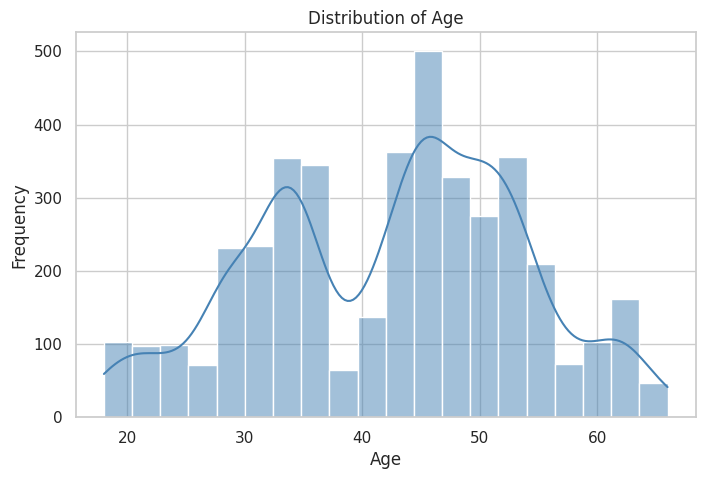

In [ ]:

# STEP 6: Univariate Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

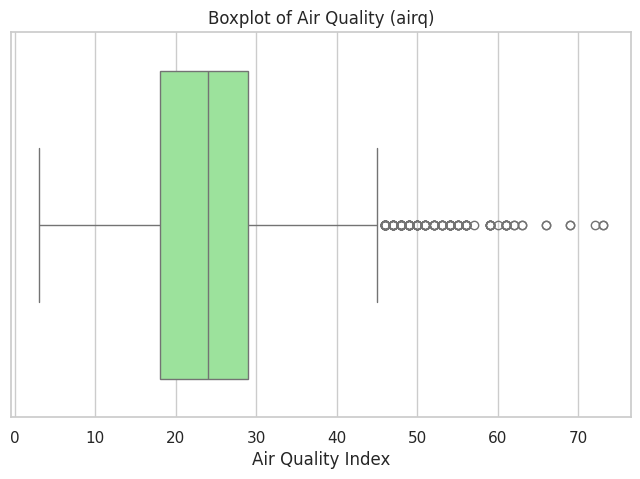

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['airq'], color='lightgreen')
plt.title("Boxplot of Air Quality (airq)")
plt.xlabel("Air Quality Index")
plt.show()

/tmp/ipykernel_898/151015633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sex'], palette='pastel')


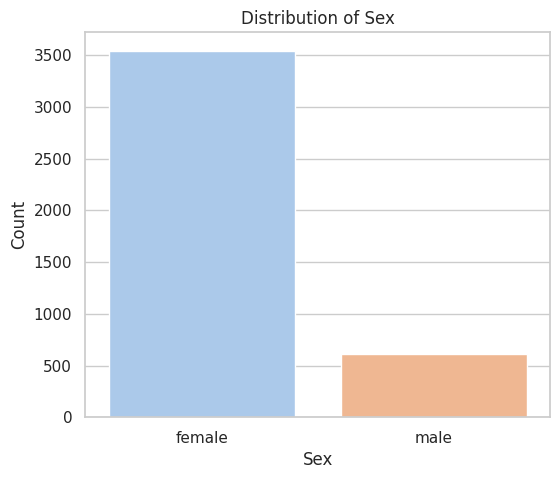

In [ ]:

plt.figure(figsize=(6,5))
sns.countplot(x=df['sex'], palette='pastel')
plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_898/2139300821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['hatype'], palette='muted')


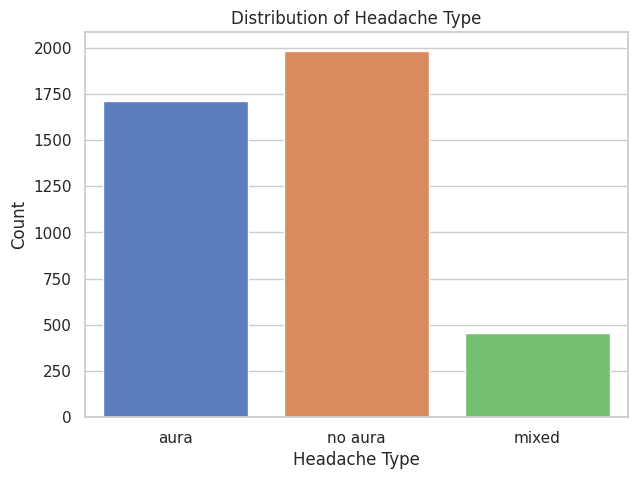

In [ ]:

plt.figure(figsize=(7,5))
sns.countplot(x=df['hatype'], palette='muted')
plt.title("Distribution of Headache Type")
plt.xlabel("Headache Type")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_898/3153503421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['medication'], palette='Set2')


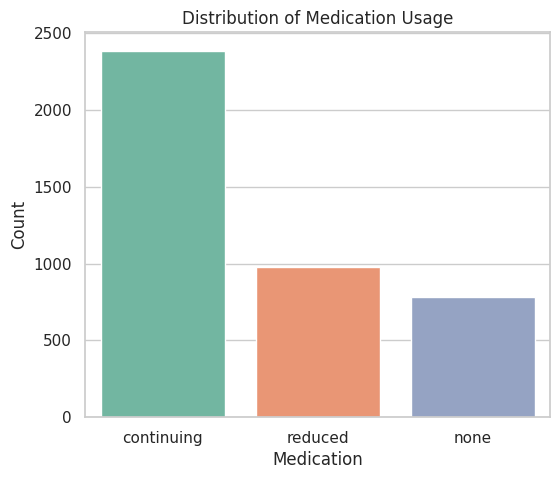

In [ ]:

plt.figure(figsize=(6,5))
sns.countplot(x=df['medication'], palette='Set2')
plt.title("Distribution of Medication Usage")
plt.xlabel("Medication")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_898/2304956679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hatype', y='age', data=df, palette='pastel')


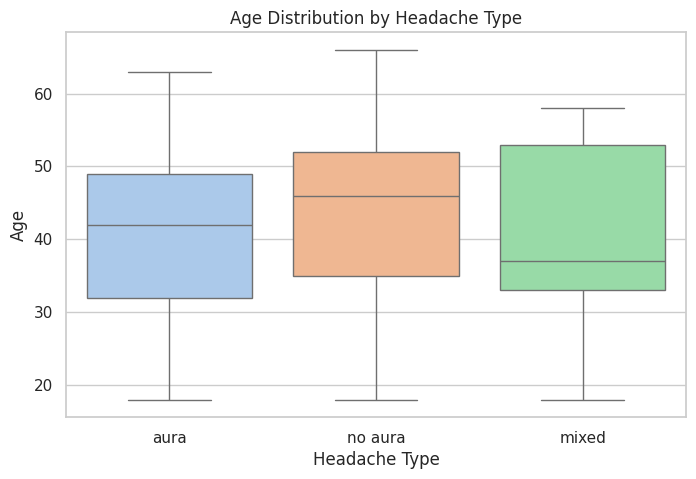

In [ ]:

# STEP 7: Bivariate Analysis

plt.figure(figsize=(8,5))
sns.boxplot(x='hatype', y='age', data=df, palette='pastel')
plt.title("Age Distribution by Headache Type")
plt.xlabel("Headache Type")
plt.ylabel("Age")
plt.show()

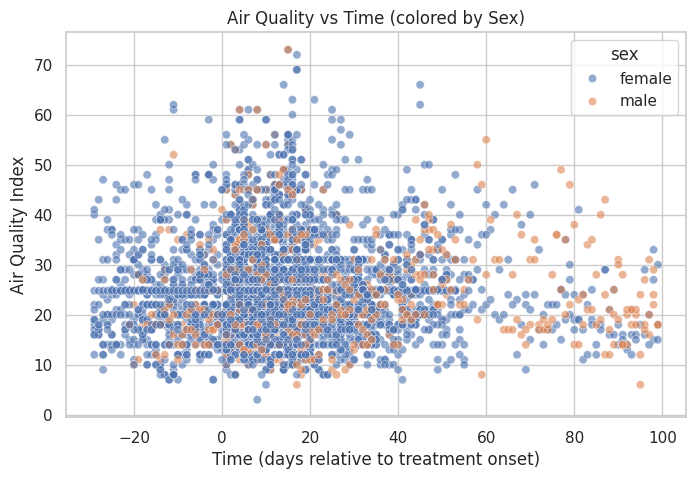

In [ ]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='time', y='airq', data=df, hue='sex', alpha=0.6)
plt.title("Air Quality vs Time (colored by Sex)")
plt.xlabel("Time (days relative to treatment onset)")
plt.ylabel("Air Quality Index")
plt.show()

/tmp/ipykernel_898/2751527088.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hatype', y='airq', data=df, palette='Set2', ci=None)
/tmp/ipykernel_898/2751527088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hatype', y='airq', data=df, palette='Set2', ci=None)


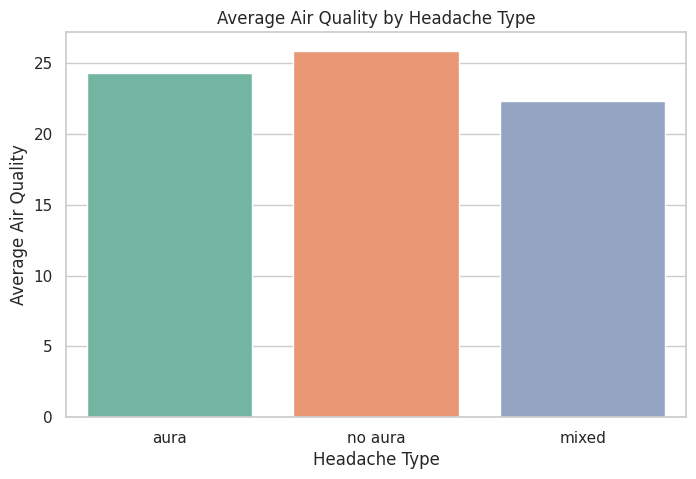

In [ ]:

plt.figure(figsize=(8,5))
sns.barplot(x='hatype', y='airq', data=df, palette='Set2', ci=None)
plt.title("Average Air Quality by Headache Type")
plt.xlabel("Headache Type")
plt.ylabel("Average Air Quality")
plt.show()

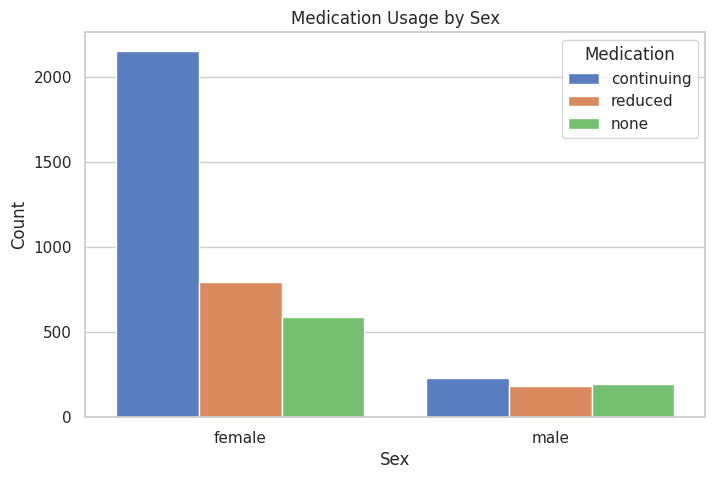

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='medication', data=df, palette='muted')
plt.title("Medication Usage by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Medication")
plt.show()

/tmp/ipykernel_898/1290632471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='medication', y='age', data=df, palette='coolwarm')


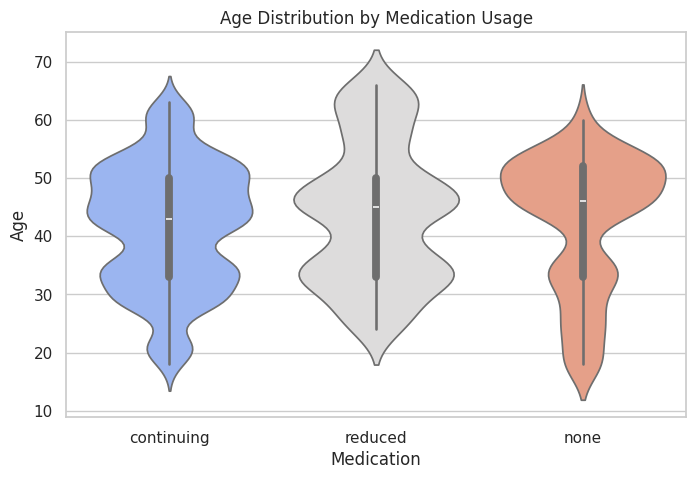

In [ ]:

plt.figure(figsize=(8,5))
sns.violinplot(x='medication', y='age', data=df, palette='coolwarm')
plt.title("Age Distribution by Medication Usage")
plt.xlabel("Medication")
plt.ylabel("Age")
plt.show()

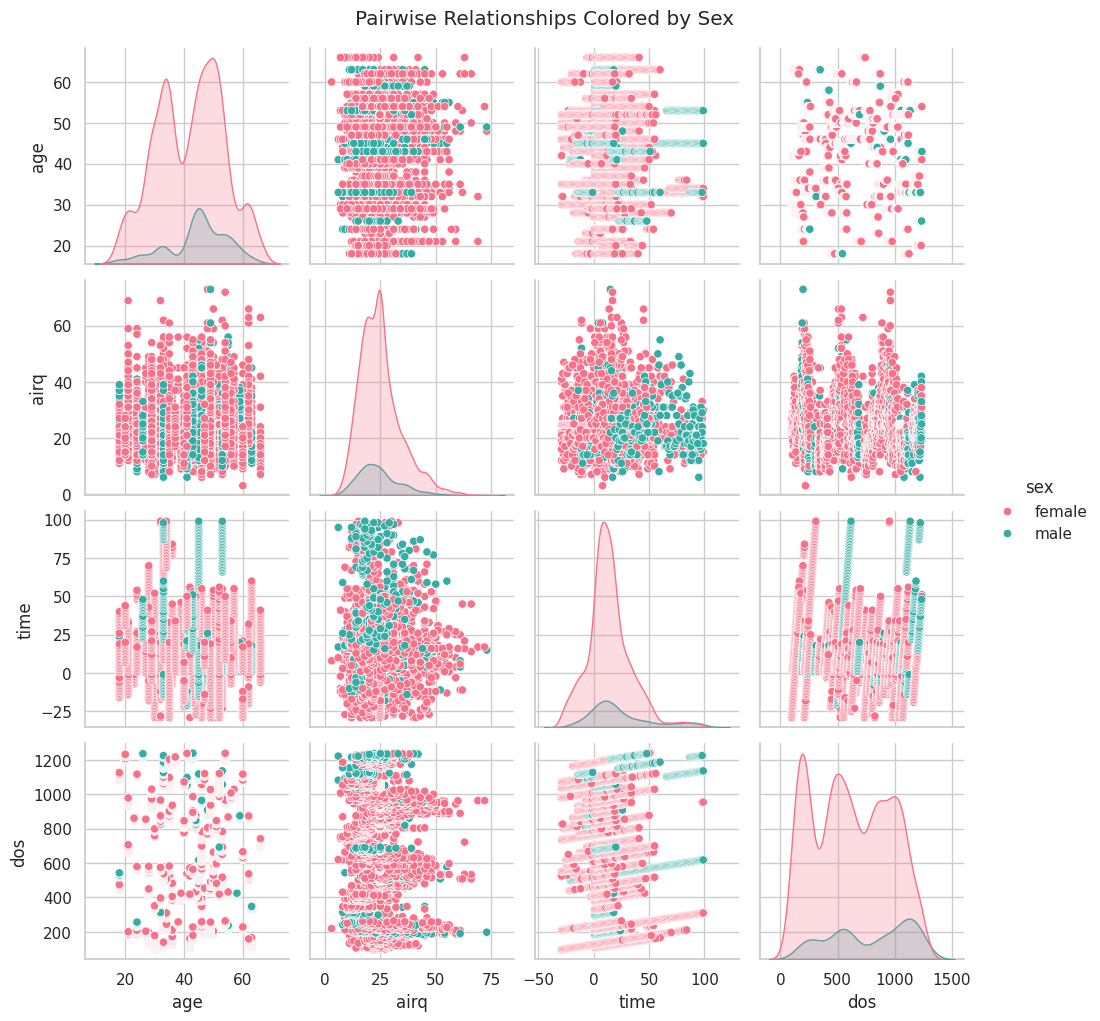

In [ ]:

# STEP 8: Multivariate Analysis

sns.pairplot(df, vars=['age', 'airq', 'time', 'dos'], hue='sex', palette='husl')
plt.suptitle("Pairwise Relationships Colored by Sex", y=1.02)
plt.show()

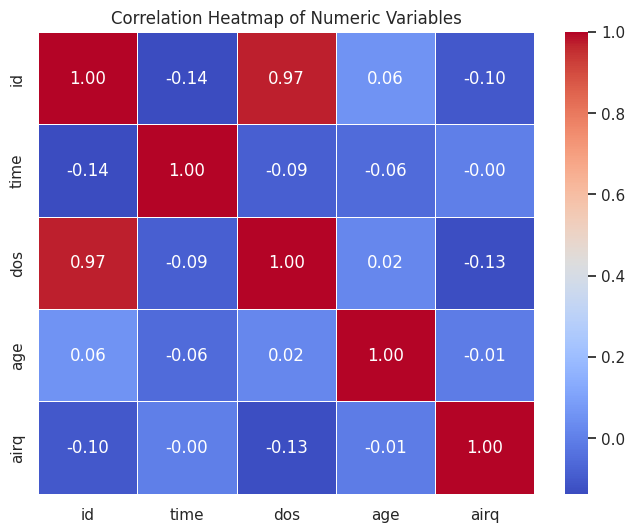

In [ ]:

plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

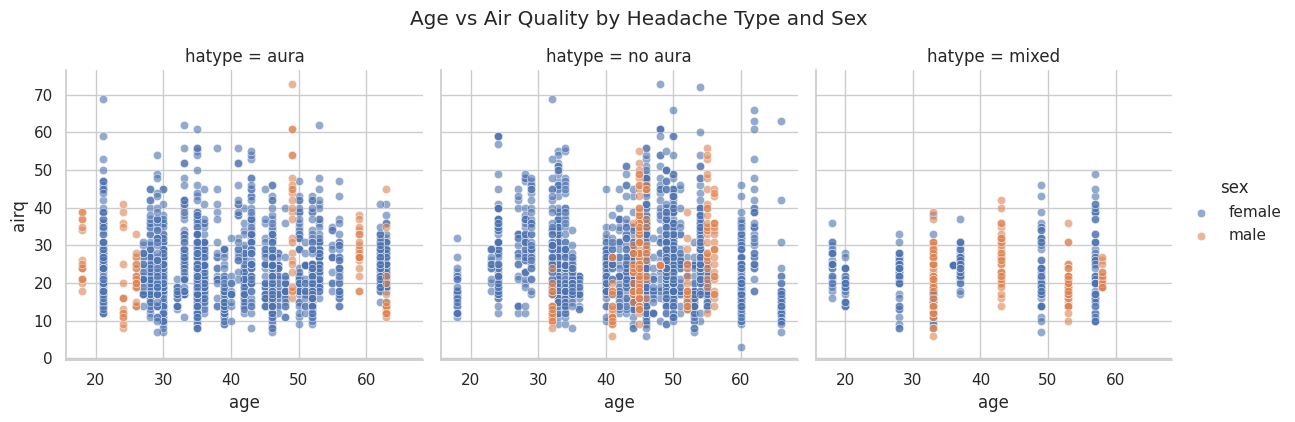

In [ ]:

g = sns.FacetGrid(df, col='hatype', hue='sex', height=4)
g.map(sns.scatterplot, 'age', 'airq', alpha=0.6)
g.add_legend()
g.fig.suptitle("Age vs Air Quality by Headache Type and Sex", y=1.05)
plt.show()

/tmp/ipykernel_898/662168854.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hatype', y='airq', hue='medication', data=df, palette='Set1', ci=None)


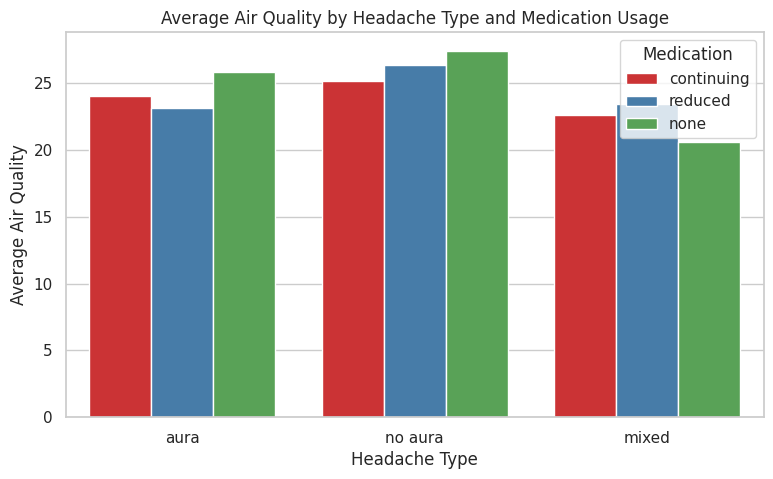

In [ ]:

plt.figure(figsize=(9,5))
sns.barplot(x='hatype', y='airq', hue='medication', data=df, palette='Set1', ci=None)
plt.title("Average Air Quality by Headache Type and Medication Usage")
plt.xlabel("Headache Type")
plt.ylabel("Average Air Quality")
plt.legend(title="Medication")
plt.show()

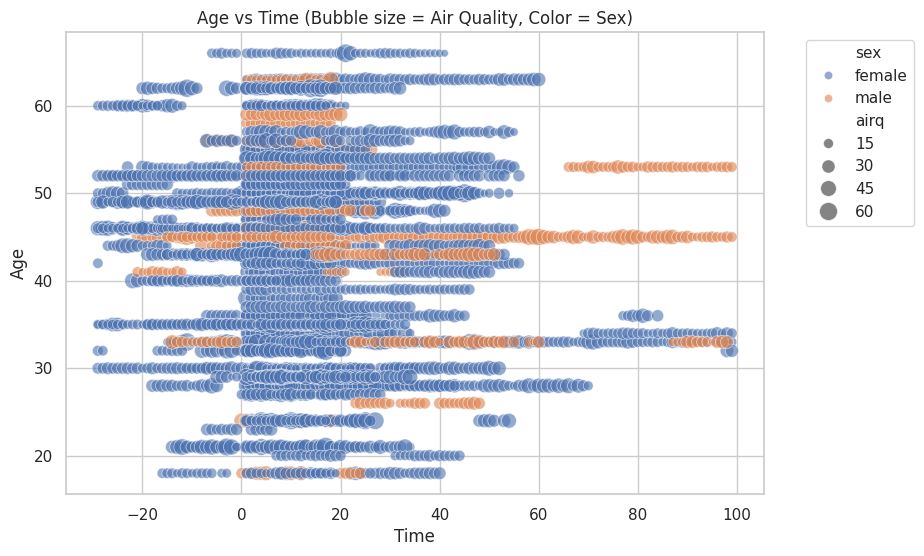

In [ ]:

plt.figure(figsize=(9,6))
sns.scatterplot(x='time', y='age', size='airq', hue='sex', data=df, sizes=(20, 200), alpha=0.6)
plt.title("Age vs Time (Bubble size = Air Quality, Color = Sex)")
plt.xlabel("Time")
plt.ylabel("Age")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [4]:
# ============================================
# phase 2
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Reload dataset
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/KosteckiDillon.csv"
df = pd.read_csv(url)

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
elif 'rownames' in df.columns:
    df.drop(columns=['rownames'], inplace=True)

df.drop_duplicates(inplace=True)

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Dataset reloaded and cleaned. Shape:", df.shape)
df.head()


Dataset reloaded and cleaned. Shape: (4151, 9)


,id,time,dos,hatype,age,airq,medication,headache,sex
0,1,-11,753,aura,30,9.0,continuing,yes,female
1,1,-10,754,aura,30,7.0,continuing,yes,female
2,1,-9,755,aura,30,10.0,continuing,yes,female
3,1,-8,756,aura,30,13.0,continuing,yes,female
4,1,-7,757,aura,30,18.0,continuing,yes,female


===== 1D ANALYSIS: AGE =====

Summary Statistics:
count    4151.000000
mean       42.366418
std        11.201438
min        18.000000
25%        33.000000
50%        44.000000
75%        50.000000
max        66.000000
Name: age, dtype: float64
Skewness: -0.15300107987103814
Kurtosis: -0.6890898236446454


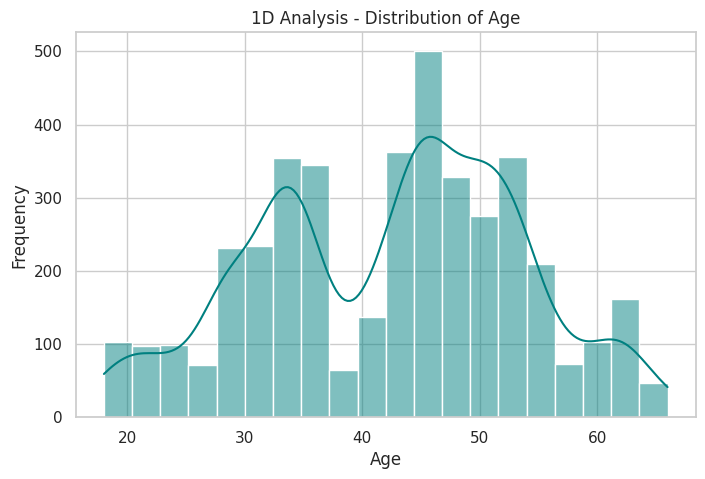

In [9]:
# ============================================
# 1D ANALYSIS - Age
# ============================================
print("===== 1D ANALYSIS: AGE =====")

data1d = df["age"].dropna()

print("\nSummary Statistics:")
print(data1d.describe())
print("Skewness:", data1d.skew())
print("Kurtosis:", data1d.kurt())

plt.figure(figsize=(8,5))
sns.histplot(data1d, bins=20, kde=True, color='teal')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("1D Analysis - Distribution of Age")
plt.show()

===== 1D ANALYSIS: AIR QUALITY (airq) =====

Summary Statistics:
count    4151.000000
mean       24.825006
std         9.515200
min         3.000000
25%        18.000000
50%        24.000000
75%        29.000000
max        73.000000
Name: airq, dtype: float64
Skewness: 1.075906537200772
Kurtosis: 1.6915425024633488


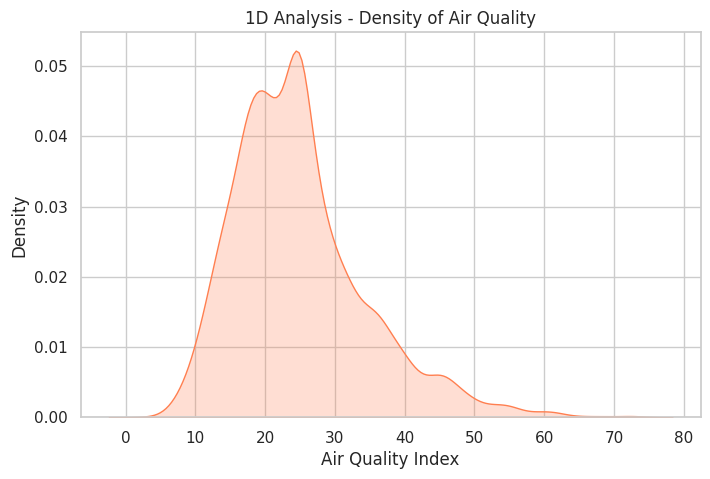

In [10]:
# ============================================
# 1D ANALYSIS - Air Quality
# ============================================
print("===== 1D ANALYSIS: AIR QUALITY (airq) =====")

data1d = df["airq"].dropna()

print("\nSummary Statistics:")
print(data1d.describe())
print("Skewness:", data1d.skew())
print("Kurtosis:", data1d.kurt())

plt.figure(figsize=(8,5))
sns.kdeplot(data1d, fill=True, color='coral')
plt.xlabel("Air Quality Index")
plt.ylabel("Density")
plt.title("1D Analysis - Density of Air Quality")
plt.show()

===== 2D ANALYSIS: AGE vs AIR QUALITY =====

Correlation:
           age      airq
age   1.000000 -0.009067
airq -0.009067  1.000000


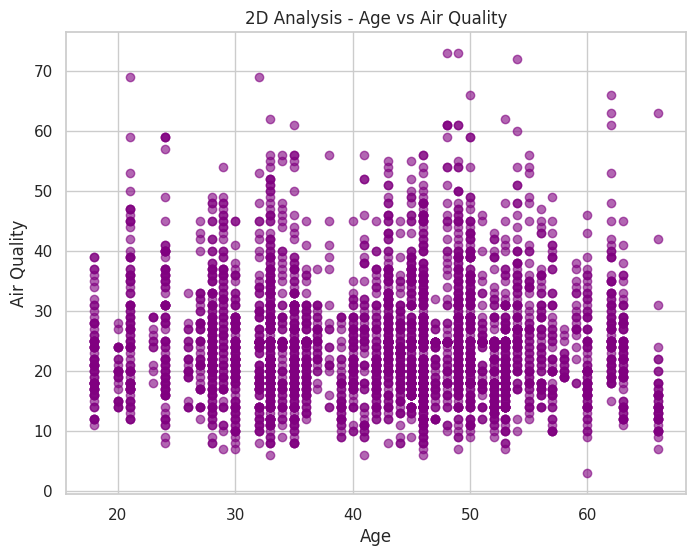

In [11]:
# ============================================
# 2D ANALYSIS - Age vs Air Quality
# ============================================
print("===== 2D ANALYSIS: AGE vs AIR QUALITY =====")

data2d = df[["age", "airq"]].dropna()

print("\nCorrelation:")
print(data2d.corr())

plt.figure(figsize=(8,6))
plt.scatter(data2d["age"], data2d["airq"], alpha=0.6, color='purple')
plt.xlabel("Age")
plt.ylabel("Air Quality")
plt.title("2D Analysis - Age vs Air Quality")
plt.show()

===== 2D ANALYSIS: TIME vs AIR QUALITY =====

Correlation:
          time      airq
time  1.000000 -0.002536
airq -0.002536  1.000000


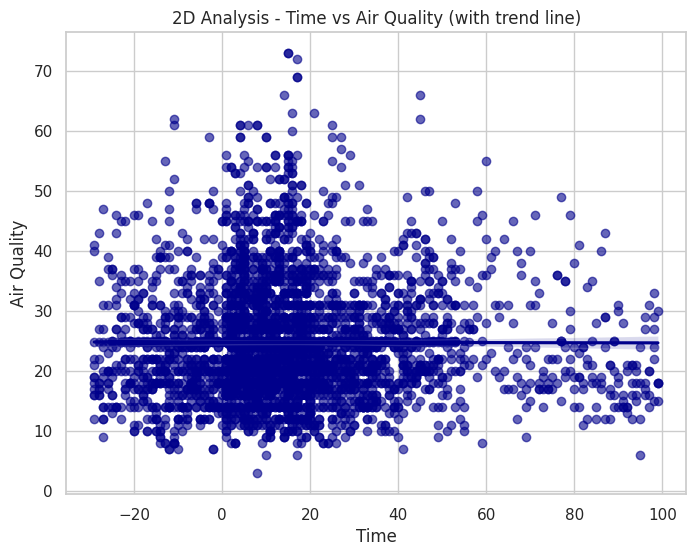

In [12]:
# ============================================
# 2D ANALYSIS - Time vs Air Quality
# ============================================
print("===== 2D ANALYSIS: TIME vs AIR QUALITY =====")

data2d = df[["time", "airq"]].dropna()

print("\nCorrelation:")
print(data2d.corr())

plt.figure(figsize=(8,6))
sns.regplot(x="time", y="airq", data=data2d, color='darkblue',
            scatter_kws={'alpha':0.6})
plt.xlabel("Time")
plt.ylabel("Air Quality")
plt.title("2D Analysis - Time vs Air Quality (with trend line)")
plt.show()

===== 3D ANALYSIS: AGE, AIR QUALITY, TIME =====

Correlation Matrix:
           age      airq      time
age   1.000000 -0.009067 -0.055771
airq -0.009067  1.000000 -0.002536
time -0.055771 -0.002536  1.000000


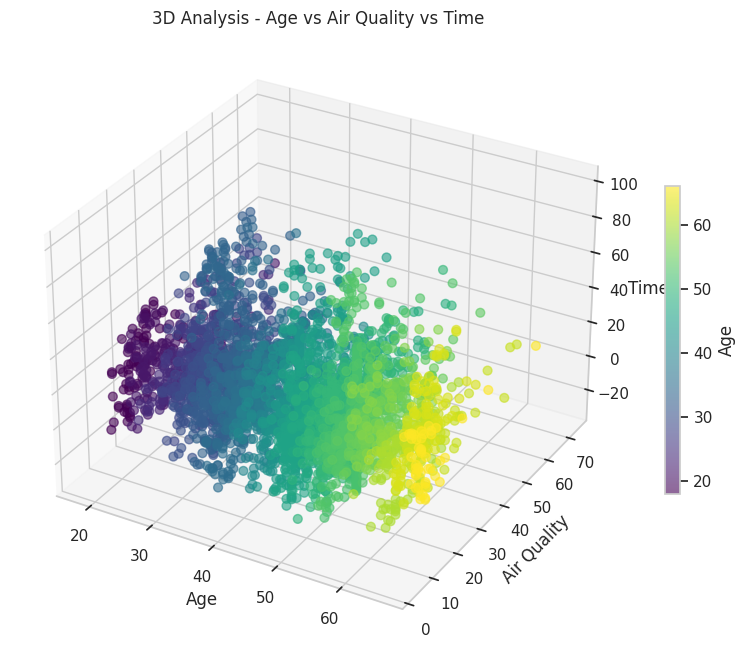

In [13]:
# ============================================
# 3D ANALYSIS - Age, Air Quality, Time
# ============================================
print("===== 3D ANALYSIS: AGE, AIR QUALITY, TIME =====")

data3d = df[["age", "airq", "time"]].dropna()

print("\nCorrelation Matrix:")
print(data3d.corr())

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(data3d["age"], data3d["airq"], data3d["time"],
                      c=data3d["age"], cmap='viridis', alpha=0.6, s=40)

ax.set_xlabel('Age')
ax.set_ylabel('Air Quality')
ax.set_zlabel('Time')
ax.set_title('3D Analysis - Age vs Air Quality vs Time')

fig.colorbar(scatter, ax=ax, shrink=0.5, label='Age')
plt.show()

===== 3D ANALYSIS: AGE, AIR QUALITY, DOS (by Sex) =====

Correlation Matrix (numeric columns):
           age      airq       dos
age   1.000000 -0.009067  0.021301
airq -0.009067  1.000000 -0.130015
dos   0.021301 -0.130015  1.000000

Group means by Sex:
              age       airq         dos
sex                                     
female  41.968679  24.884707  623.191874
male    44.688633  24.476442  783.622735


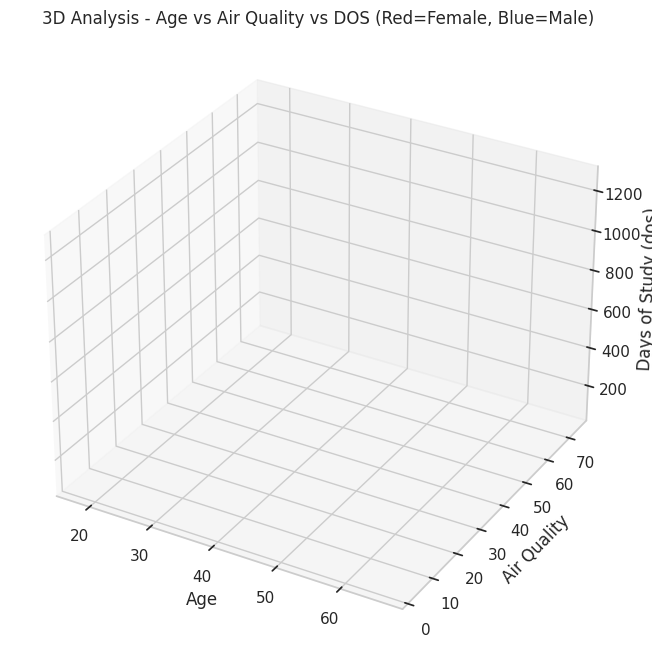

In [14]:
# ============================================
# 3D ANALYSIS - Age, Air Quality, DOS (by Sex)
# ============================================
print("===== 3D ANALYSIS: AGE, AIR QUALITY, DOS (by Sex) =====")

data3d = df[["age", "airq", "dos", "sex"]].dropna()

print("\nCorrelation Matrix (numeric columns):")
print(data3d[["age", "airq", "dos"]].corr())

print("\nGroup means by Sex:")
print(data3d.groupby("sex")[["age", "airq", "dos"]].mean())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = data3d["sex"].map({'f': 'red', 'm': 'blue'})
ax.scatter(data3d["age"], data3d["airq"], data3d["dos"], c=colors, alpha=0.6, s=40)

ax.set_xlabel('Age')
ax.set_ylabel('Air Quality')
ax.set_zlabel('Days of Study (dos)')
ax.set_title('3D Analysis - Age vs Air Quality vs DOS (Red=Female, Blue=Male)')
plt.show()

In [18]:

# ============================================
#k means
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")


try:
    df
except NameError:
    url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/KosteckiDillon.csv"
    df = pd.read_csv(url)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    elif 'rownames' in df.columns:
        df.drop(columns=['rownames'], inplace=True)
    df.drop_duplicates(inplace=True)
    categorical_cols = df.select_dtypes(include='object').columns
    for col in categorical_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

cluster_features = ['age', 'airq', 'time', 'dos']
X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("Setup complete. df shape:", df.shape, "| X_scaled shape:", X_scaled.shape)

Setup complete. df shape: (4151, 9) | X_scaled shape: (4151, 4)


===== K-MEANS: ELBOW METHOD =====
K=1, Inertia=16604.00
K=2, Inertia=13160.83
K=3, Inertia=11111.30
K=4, Inertia=9406.79
K=5, Inertia=8025.10
K=6, Inertia=7112.39
K=7, Inertia=6525.66
K=8, Inertia=6139.51
K=9, Inertia=5807.84
K=10, Inertia=5514.43


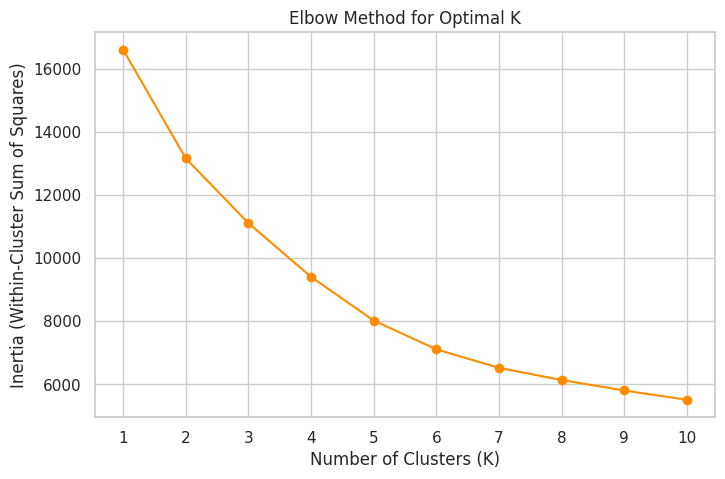

In [19]:
# ============================================
# K-MEANS - Step 1: Elbow Method
# ============================================
print("===== K-MEANS: ELBOW METHOD =====")

from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='darkorange')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.show()

===== K-MEANS: SILHOUETTE SCORES =====
K=2, Silhouette Score=0.2127
K=3, Silhouette Score=0.2213
K=4, Silhouette Score=0.2297
K=5, Silhouette Score=0.2391
K=6, Silhouette Score=0.2309
K=7, Silhouette Score=0.2367
K=8, Silhouette Score=0.2332
K=9, Silhouette Score=0.2227
K=10, Silhouette Score=0.2180


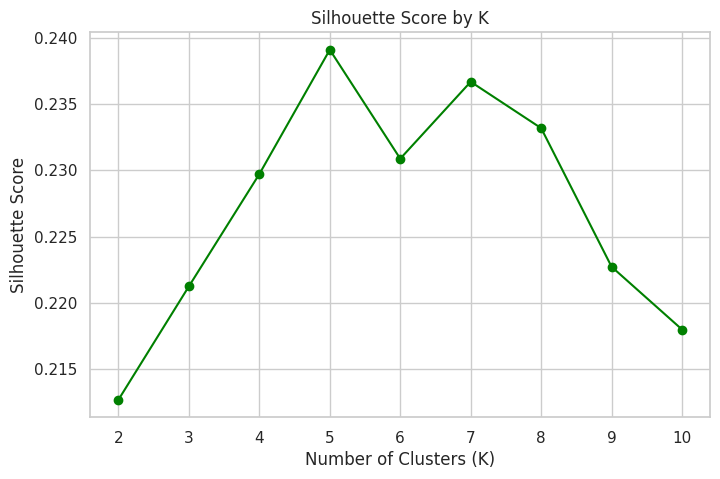

In [20]:
# ============================================
# K-MEANS - Step 2: Silhouette Score
# ============================================
print("===== K-MEANS: SILHOUETTE SCORES =====")

from sklearn.metrics import silhouette_score

sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(K_range_sil, sil_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(K_range_sil)
plt.show()

In [21]:
# ============================================
# K-MEANS - Step 3: Fit Final Model
# ============================================
print("===== K-MEANS: FINAL MODEL =====")

optimal_k = 3  # update based on elbow/silhouette plots above

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nNumber of clusters chosen: {optimal_k}")
print("\nCluster sizes:")
print(df['kmeans_cluster'].value_counts())

print("\nCluster means (original scale):")
print(df.groupby('kmeans_cluster')[cluster_features].mean())

===== K-MEANS: FINAL MODEL =====

Number of clusters chosen: 3

Cluster sizes:
kmeans_cluster
2    1857
1    1551
0     743
Name: count, dtype: int64

Cluster means (original scale):
                      age       airq       time         dos
kmeans_cluster                                             
0               43.251682  40.317631  11.993271  538.709287
1               40.284333  21.766602  22.638943  346.974855
2               43.751212  21.180722  10.840603  940.135703


===== K-MEANS: 2D CLUSTER VISUALIZATION (Age vs Air Quality) =====


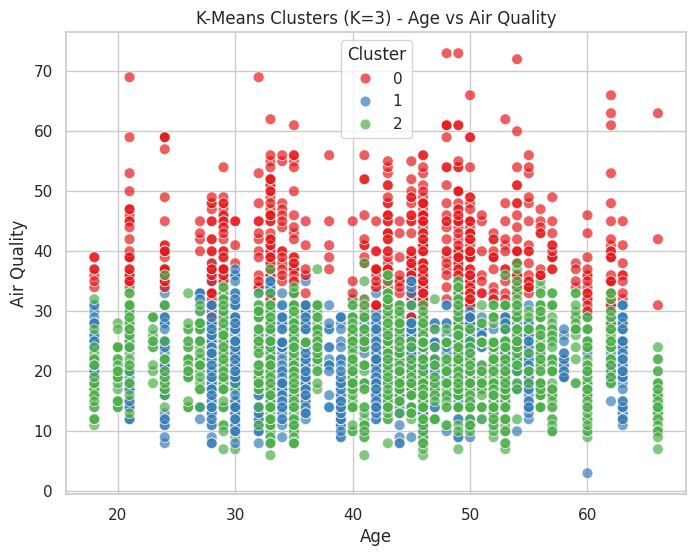

In [22]:
# ============================================
# K-MEANS - Step 4: 2D Cluster Visualization
# ============================================
print("===== K-MEANS: 2D CLUSTER VISUALIZATION (Age vs Air Quality) =====")

plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='airq', hue='kmeans_cluster', data=df,
                palette='Set1', alpha=0.7, s=60)
plt.xlabel("Age")
plt.ylabel("Air Quality")
plt.title(f"K-Means Clusters (K={optimal_k}) - Age vs Air Quality")
plt.legend(title="Cluster")
plt.show()

===== K-MEANS: 3D CLUSTER VISUALIZATION =====


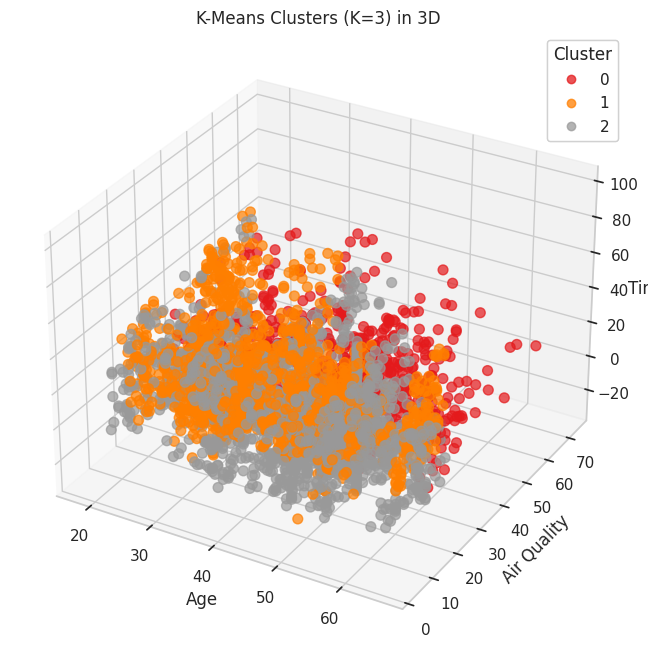

In [23]:
# ============================================
# K-MEANS - Step 5: 3D Cluster Visualization
# ============================================
print("===== K-MEANS: 3D CLUSTER VISUALIZATION =====")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['age'], df['airq'], df['time'],
                      c=df['kmeans_cluster'], cmap='Set1', alpha=0.7, s=50)

ax.set_xlabel('Age')
ax.set_ylabel('Air Quality')
ax.set_zlabel('Time')
ax.set_title(f'K-Means Clusters (K={optimal_k}) in 3D')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()

===== HIERARCHICAL CLUSTERING: DENDROGRAM =====


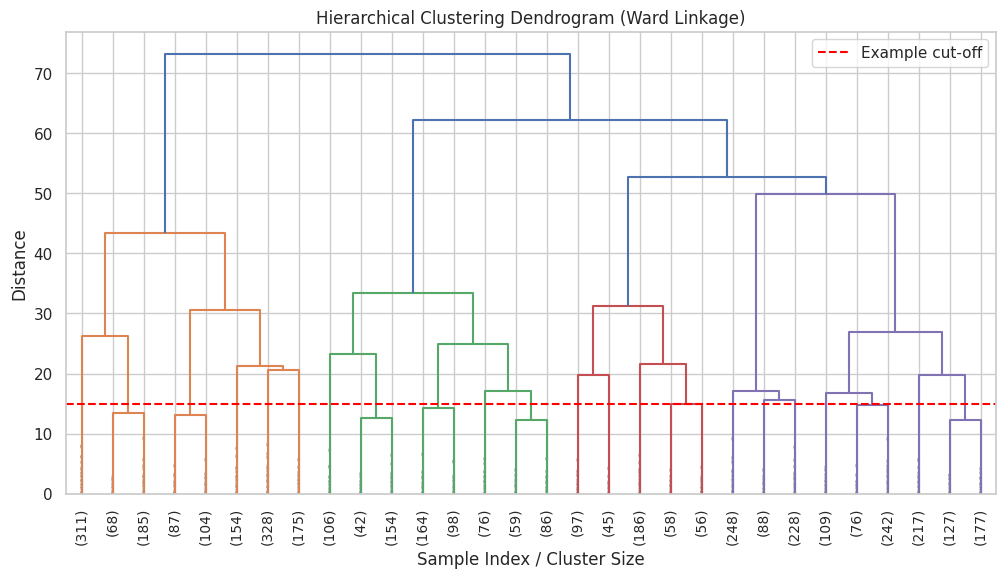

In [24]:
# ============================================
# HIERARCHICAL CLUSTERING - Step 1: Dendrogram
# ============================================
print("===== HIERARCHICAL CLUSTERING: DENDROGRAM =====")

from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90.,
           leaf_font_size=10.,
           show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index / Cluster Size")
plt.ylabel("Distance")
plt.axhline(y=15, color='red', linestyle='--', label='Example cut-off')
plt.legend()
plt.show()

In [25]:
# ============================================
# HIERARCHICAL CLUSTERING - Step 2: Fit Model with Chosen Clusters
# ============================================
print("===== HIERARCHICAL CLUSTERING: FINAL MODEL =====")

from sklearn.cluster import AgglomerativeClustering

n_clusters_hc = 3

hc = AgglomerativeClustering(n_clusters=n_clusters_hc, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)

print(f"\nNumber of clusters chosen: {n_clusters_hc}")
print("\nCluster sizes:")
print(df['hc_cluster'].value_counts())

print("\nCluster means (original scale):")
print(df.groupby('hc_cluster')[cluster_features].mean())

===== HIERARCHICAL CLUSTERING: FINAL MODEL =====

Number of clusters chosen: 3

Cluster sizes:
hc_cluster
0    1954
1    1412
2     785
Name: count, dtype: int64

Cluster means (original scale):
                  age       airq       time         dos
hc_cluster                                             
0           41.910440  22.628966  23.459570  407.024565
1           43.926346  20.982295   9.383853  981.119688
2           40.695541  37.203312   6.452229  641.508280


===== HIERARCHICAL: 2D CLUSTER VISUALIZATION (Age vs Air Quality) =====


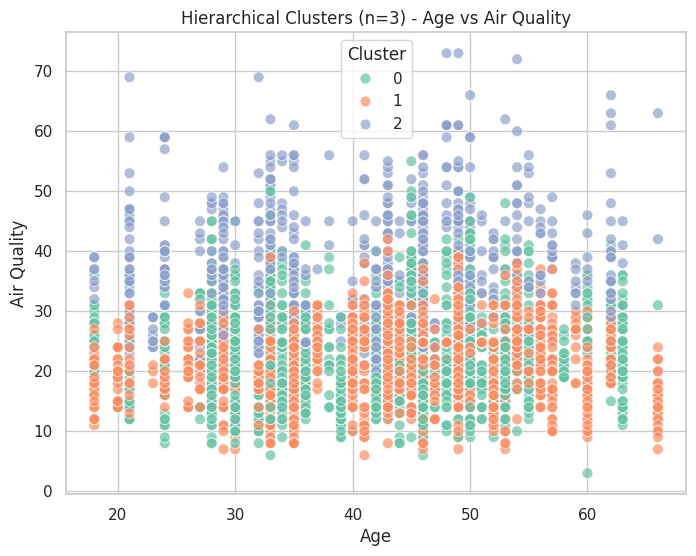

In [26]:
# ============================================
# HIERARCHICAL CLUSTERING - Step 3: 2D Visualization
# ============================================
print("===== HIERARCHICAL: 2D CLUSTER VISUALIZATION (Age vs Air Quality) =====")

plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='airq', hue='hc_cluster', data=df,
                palette='Set2', alpha=0.7, s=60)
plt.xlabel("Age")
plt.ylabel("Air Quality")
plt.title(f"Hierarchical Clusters (n={n_clusters_hc}) - Age vs Air Quality")
plt.legend(title="Cluster")
plt.show()

===== HIERARCHICAL: 3D CLUSTER VISUALIZATION =====


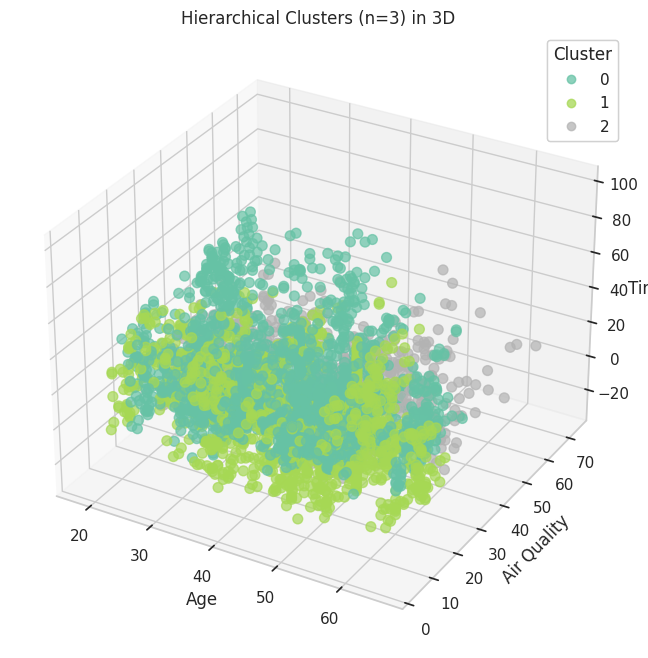

In [27]:
# ============================================
# HIERARCHICAL CLUSTERING - Step 4: 3D Visualization
# ============================================
print("===== HIERARCHICAL: 3D CLUSTER VISUALIZATION =====")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['age'], df['airq'], df['time'],
                      c=df['hc_cluster'], cmap='Set2', alpha=0.7, s=50)

ax.set_xlabel('Age')
ax.set_ylabel('Air Quality')
ax.set_zlabel('Time')
ax.set_title(f'Hierarchical Clusters (n={n_clusters_hc}) in 3D')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()

===== COMPARISON: K-MEANS vs HIERARCHICAL =====

Cross-tabulation of cluster assignments:
hc_cluster         0     1    2
kmeans_cluster                 
0                191    17  535
1               1479     5   67
2                284  1390  183


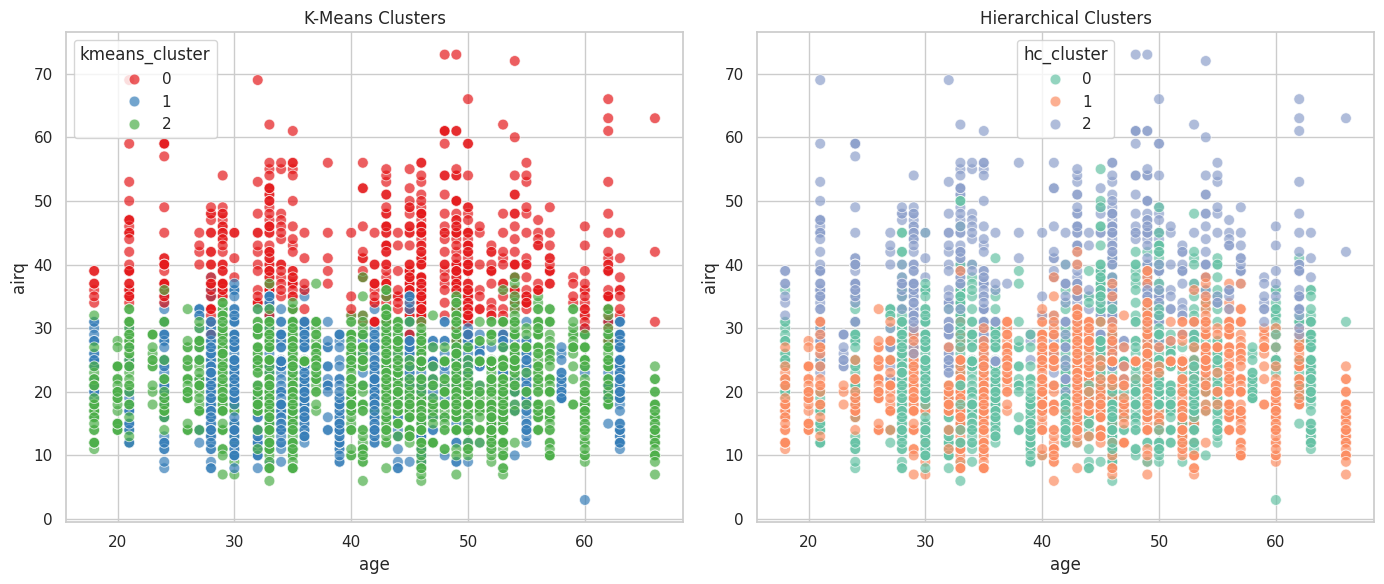

In [28]:
# ============================================
# HIERARCHICAL CLUSTERING - Step 5: Compare K-Means vs Hierarchical
# ============================================
print("===== COMPARISON: K-MEANS vs HIERARCHICAL =====")

comparison = pd.crosstab(df['kmeans_cluster'], df['hc_cluster'])
print("\nCross-tabulation of cluster assignments:")
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='age', y='airq', hue='kmeans_cluster', data=df,
                palette='Set1', alpha=0.7, s=60, ax=axes[0])
axes[0].set_title("K-Means Clusters")

sns.scatterplot(x='age', y='airq', hue='hc_cluster', data=df,
                palette='Set2', alpha=0.7, s=60, ax=axes[1])
axes[1].set_title("Hierarchical Clusters")

plt.tight_layout()
plt.show()